# Exercise B.2 — Memetic Algorithms for TSP

This notebook compares a **simple EA** and a **memetic algorithm (MA)** for the Travelling Salesman Problem.

The MA extends the EA with **2-opt local search** applied to each offspring.

**EA configuration:**
- Permutation representation
- Tournament selection (K=5)
- Order crossover (OX) with p_c = 0.8
- Swap mutation with probability mu = 0.3
- Population size N = 100
- Generational replacement, no elitism

**Datasets:**
1. `file-tsp.txt` — 50 cities (custom instance)
2. TSPLIB benchmark instance (download a `.tsp` file and place it in this directory)

**Code structure:**
- `tsp_ea.py` — Core EA/MA (selection, crossover, mutation, 2-opt, runners)
- `experiments_b2.py` — Experiment runners for generation-based and time-based comparisons
- `plotting_b2.py` — Visualization functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tsp_ea import (
    load_tsp_coordinates,
    load_tsplib,
    compute_distance_matrix,
    tour_distance,
    run_ea,
    run_ma,
)
from experiments_b2 import (
    load_dataset,
    experiment_generations,
    experiment_timed,
)
from plotting_b2 import (
    plot_convergence_generations,
    plot_convergence_timed,
    plot_final_distances,
    plot_tour,
    plot_time_comparison,
    plot_combined_convergence_gen,
    plot_combined_convergence_timed,
    plot_combined_final_distances,
    plot_combined_time_comparison,
    summary_table,
)

N_RUNS = 10
N_POP = 100
G_MAX = 200
K = 5
P_C = 0.8
MU = 0.3

## Load datasets

In [2]:
# Dataset 1: custom 50-city instance
coords_custom, dist_custom = load_dataset("file-tsp", "file-tsp.txt")
print(f"Custom dataset: {len(coords_custom)} cities")

# Dataset 2: TSPLIB instance
# Download a .tsp file from http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/
# e.g., eil51.tsp, berlin52.tsp, or att48.tsp
TSPLIB_FILE = "eil51.tsp"  # <-- change this to your downloaded file
coords_tsplib, dist_tsplib = load_dataset("tsplib", TSPLIB_FILE)
print(f"TSPLIB dataset: {len(coords_tsplib)} cities")

Custom dataset: 50 cities
TSPLIB dataset: 51 cities


## B.2.1 — Generation-based comparison (same generations, unfair)

First, we compare EA and MA using the **same number of generations**.
This is intentionally unfair: the MA performs additional 2-opt local search
each generation, consuming significantly more wall-clock time per generation.

### Dataset 1: custom 50-city instance

In [3]:
results_gen_custom = experiment_generations(
    dist_custom, n_runs=N_RUNS, N=N_POP, G_max=G_MAX, K=K, p_c=P_C, mu=MU
)

  Running simple EA (10 runs, 15 workers)...
    Run 1/10: best = 165.00, time = 0.4s
    Run 2/10: best = 173.95, time = 0.4s
    Run 3/10: best = 156.50, time = 0.5s
    Run 4/10: best = 151.56, time = 0.4s
    Run 5/10: best = 158.86, time = 0.4s
    Run 6/10: best = 176.20, time = 0.5s
    Run 7/10: best = 149.41, time = 0.5s
    Run 8/10: best = 169.08, time = 0.4s
    Run 9/10: best = 175.17, time = 0.4s
    Run 10/10: best = 153.38, time = 0.5s
  Running memetic algorithm (10 runs, 15 workers)...
    Run 1/10: best = 119.94, time = 23.8s
    Run 2/10: best = 119.94, time = 22.9s
    Run 3/10: best = 119.94, time = 30.9s
    Run 4/10: best = 119.94, time = 32.6s
    Run 5/10: best = 119.94, time = 23.0s
    Run 6/10: best = 119.94, time = 24.8s
    Run 7/10: best = 119.94, time = 23.1s
    Run 8/10: best = 119.94, time = 23.5s
    Run 9/10: best = 119.94, time = 32.7s
    Run 10/10: best = 119.94, time = 32.8s


In [4]:
summary_table(results_gen_custom, "Custom 50-city (generation-based)")


  Custom 50-city (generation-based)
  Simple EA:
    Best distance: 149.41
    Mean distance: 162.91 +/- 9.75
    Mean time:     0.4s
  MA (EA + 2-opt):
    Best distance: 119.94
    Mean distance: 119.94 +/- 0.00
    Mean time:     27.0s



### Dataset 2: TSPLIB instance

In [5]:
results_gen_tsplib = experiment_generations(
    dist_tsplib, n_runs=N_RUNS, N=N_POP, G_max=G_MAX, K=K, p_c=P_C, mu=MU
)

  Running simple EA (10 runs, 15 workers)...
    Run 1/10: best = 562.16, time = 0.5s
    Run 2/10: best = 676.36, time = 0.4s
    Run 3/10: best = 608.90, time = 0.4s
    Run 4/10: best = 549.20, time = 0.4s
    Run 5/10: best = 576.24, time = 0.5s
    Run 6/10: best = 545.24, time = 0.4s
    Run 7/10: best = 598.35, time = 0.4s
    Run 8/10: best = 600.44, time = 0.5s
    Run 9/10: best = 600.98, time = 0.4s
    Run 10/10: best = 592.58, time = 0.5s
  Running memetic algorithm (10 runs, 15 workers)...
    Run 1/10: best = 428.98, time = 23.3s
    Run 2/10: best = 428.98, time = 33.8s
    Run 3/10: best = 428.87, time = 25.7s
    Run 4/10: best = 428.87, time = 24.0s
    Run 5/10: best = 428.87, time = 23.6s
    Run 6/10: best = 428.87, time = 30.5s
    Run 7/10: best = 428.98, time = 30.7s
    Run 8/10: best = 428.87, time = 25.3s
    Run 9/10: best = 428.87, time = 24.0s
    Run 10/10: best = 428.87, time = 33.5s


In [6]:
summary_table(results_gen_tsplib, "TSPLIB (generation-based)")


  TSPLIB (generation-based)
  Simple EA:
    Best distance: 545.24
    Mean distance: 591.04 +/- 35.70
    Mean time:     0.4s
  MA (EA + 2-opt):
    Best distance: 428.87
    Mean distance: 428.90 +/- 0.05
    Mean time:     27.4s



### Combined generation-based results

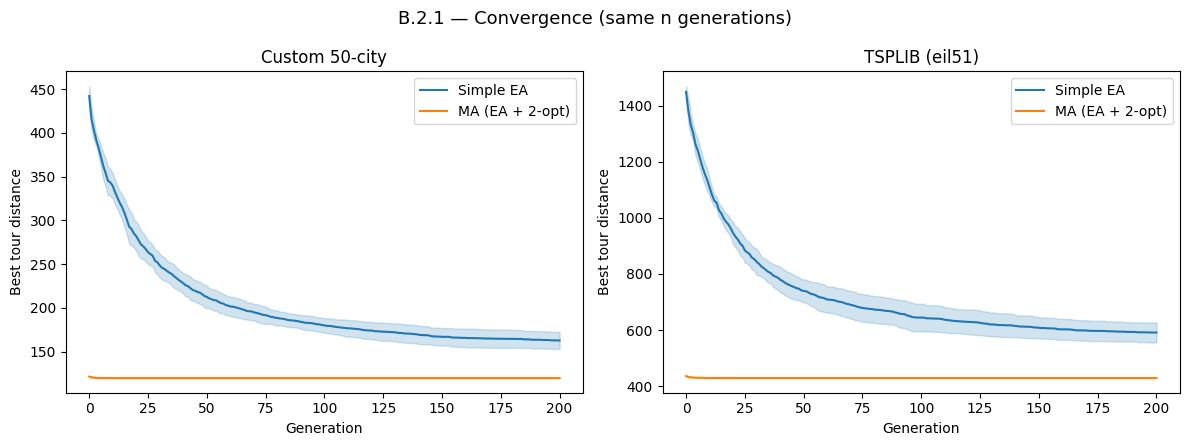

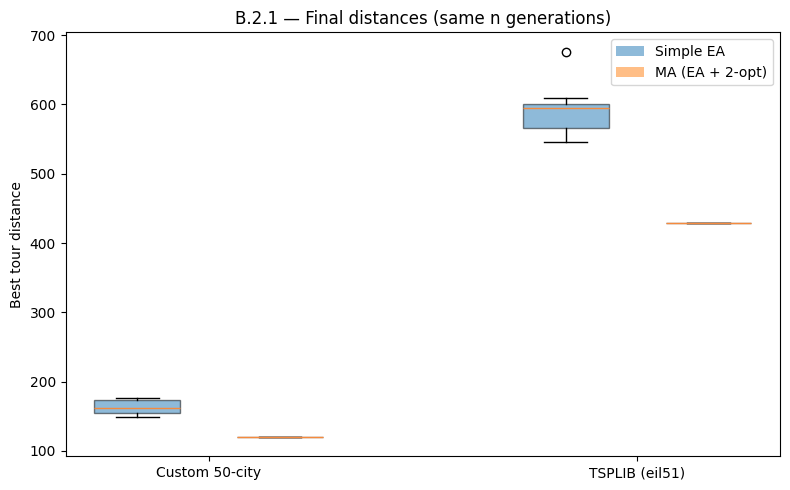

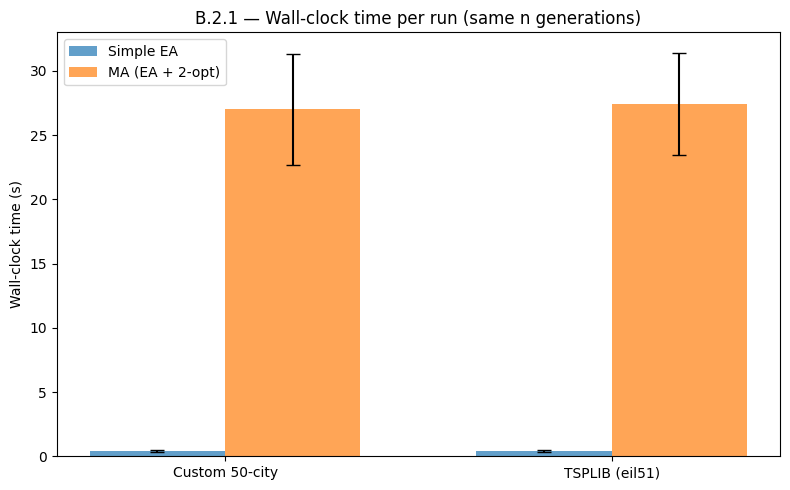

In [15]:
fig = plot_combined_convergence_gen(results_gen_custom, results_gen_tsplib,
    title="Convergence (same n generations)")
plt.show()

fig = plot_combined_final_distances(results_gen_custom, results_gen_tsplib,
    title="Final distances (same n generations)")
plt.show()

fig = plot_combined_time_comparison(results_gen_custom, results_gen_tsplib,
    title="Wall-clock time per run (same n generations)")
plt.show()

## B.2.1 Discussion — Is same-generation comparison fair?

Comparing EA and MA with the same number of generations is **not a fair comparison**.

The MA performs 2-opt local search on every offspring, which is computationally
expensive. Even though both algorithms run the same number of generations, the MA
uses orders of magnitude more wall-clock time (as shown in the bar chart above).

A fairer comparison gives both algorithms the same **wall-clock time budget**, so
the EA can run many more generations to compensate for not having local search.
This equalizes the total computational resources available to each algorithm.

## B.2.2 — Time-based comparison (fair)

We give both algorithms the same wall-clock time budget.
The budget is set to the mean time the MA used in the generation-based experiment,
so the MA runs roughly the same number of generations as before, while the EA
gets many more generations to compensate.

In [8]:
# Use the MA's wall-clock time from generation-based runs as the budget
time_budget_custom = np.mean([r["elapsed"] for r in results_gen_custom["ma"]])
time_budget_tsplib = np.mean([r["elapsed"] for r in results_gen_tsplib["ma"]])
print(f"Time budget for custom dataset: {time_budget_custom:.1f}s")
print(f"Time budget for TSPLIB dataset: {time_budget_tsplib:.1f}s")

Time budget for custom dataset: 27.0s
Time budget for TSPLIB dataset: 27.4s


### Dataset 1: custom 50-city instance

In [9]:
results_timed_custom = experiment_timed(
    dist_custom, n_runs=N_RUNS, time_budget=time_budget_custom,
    N=N_POP, K=K, p_c=P_C, mu=MU
)

  Running simple EA (budget=27.0s, 10 runs, 15 workers)...
    Run 1/10: best = 144.80, gens = 14732
    Run 2/10: best = 152.55, gens = 9553
    Run 3/10: best = 146.56, gens = 13708
    Run 4/10: best = 160.37, gens = 14649
    Run 5/10: best = 151.69, gens = 8400
    Run 6/10: best = 127.73, gens = 9520
    Run 7/10: best = 151.87, gens = 14925
    Run 8/10: best = 173.05, gens = 8417
    Run 9/10: best = 135.21, gens = 15027
    Run 10/10: best = 142.90, gens = 13702
  Running MA (budget=27.0s, 10 runs, 15 workers)...
    Run 1/10: best = 119.94, gens = 241
    Run 2/10: best = 119.94, gens = 241
    Run 3/10: best = 119.94, gens = 230
    Run 4/10: best = 119.94, gens = 123
    Run 5/10: best = 119.94, gens = 124
    Run 6/10: best = 119.94, gens = 249
    Run 7/10: best = 119.94, gens = 245
    Run 8/10: best = 119.94, gens = 236
    Run 9/10: best = 119.94, gens = 121
    Run 10/10: best = 119.94, gens = 124


In [10]:
summary_table(results_timed_custom, "Custom 50-city (time-based)")


  Custom 50-city (time-based)
  Simple EA:
    Best distance: 127.73
    Mean distance: 148.67 +/- 11.99
    Mean gens:     12263
  MA (EA + 2-opt):
    Best distance: 119.94
    Mean distance: 119.94 +/- 0.00
    Mean gens:     193



### Dataset 2: TSPLIB instance

In [11]:
results_timed_tsplib = experiment_timed(
    dist_tsplib, n_runs=N_RUNS, time_budget=time_budget_tsplib,
    N=N_POP, K=K, p_c=P_C, mu=MU
)

  Running simple EA (budget=27.4s, 10 runs, 15 workers)...
    Run 1/10: best = 580.67, gens = 8399
    Run 2/10: best = 528.72, gens = 8429
    Run 3/10: best = 516.87, gens = 14966
    Run 4/10: best = 524.46, gens = 14956
    Run 5/10: best = 498.04, gens = 15081
    Run 6/10: best = 504.80, gens = 15170
    Run 7/10: best = 542.19, gens = 15082
    Run 8/10: best = 514.79, gens = 15080
    Run 9/10: best = 543.46, gens = 8403
    Run 10/10: best = 596.55, gens = 8433
  Running MA (budget=27.4s, 10 runs, 15 workers)...
    Run 1/10: best = 428.98, gens = 239
    Run 2/10: best = 428.87, gens = 243
    Run 3/10: best = 428.87, gens = 131
    Run 4/10: best = 428.87, gens = 246
    Run 5/10: best = 428.87, gens = 247
    Run 6/10: best = 428.98, gens = 240
    Run 7/10: best = 429.53, gens = 256
    Run 8/10: best = 428.87, gens = 122
    Run 9/10: best = 428.98, gens = 120
    Run 10/10: best = 428.87, gens = 124


In [12]:
summary_table(results_timed_tsplib, "TSPLIB (time-based)")


  TSPLIB (time-based)
  Simple EA:
    Best distance: 498.04
    Mean distance: 535.05 +/- 30.27
    Mean gens:     12400
  MA (EA + 2-opt):
    Best distance: 428.87
    Mean distance: 428.97 +/- 0.19
    Mean gens:     197



### Combined time-based results

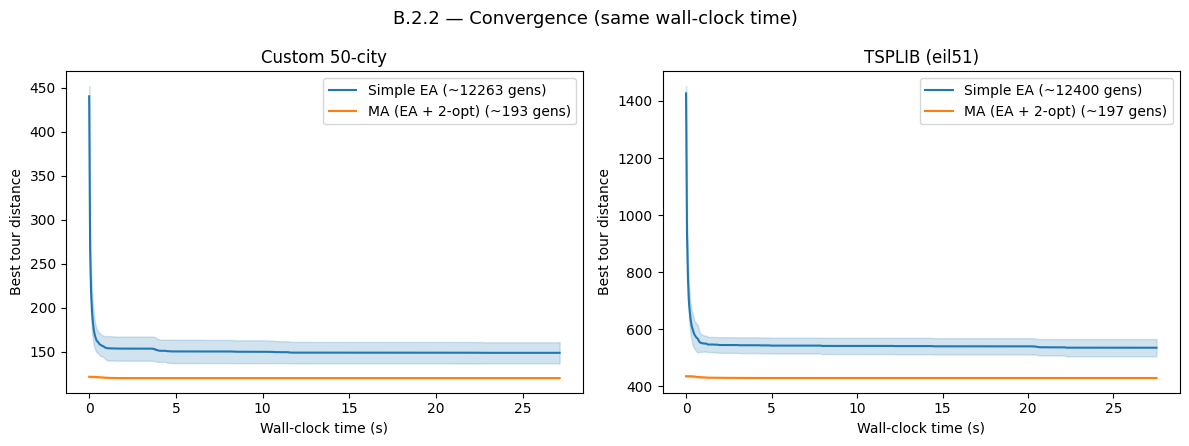

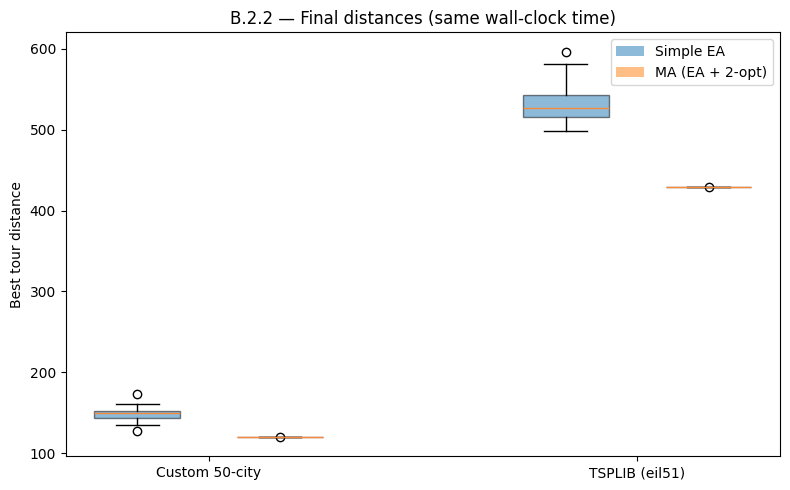

In [14]:
fig = plot_combined_convergence_timed(results_timed_custom, results_timed_tsplib,
    title="Convergence (same wall-clock time)")
plt.show()

fig = plot_combined_final_distances(results_timed_custom, results_timed_tsplib,
    title="Final distances (same wall-clock time)")
plt.show()

## Discussion

**Does the addition of local search improve performance?**

- In the **generation-based** (unfair) comparison, the MA clearly outperforms the simple EA, but it also uses far more computation time due to 2-opt.
- In the **time-based** (fair) comparison, both algorithms get the same wall-clock time. The EA can run many more generations, but the MA typically still produces better solutions because 2-opt efficiently exploits the local neighbourhood of each solution.
- The key insight is that local search and evolutionary search are complementary: the EA provides global exploration (crossover recombines diverse tours), while 2-opt provides local exploitation (removes crossing edges). Together they outperform either approach alone, even when given equal computational resources.